<div class="usecase-title"><h2><b>Industry-Level Business Distribution and Employment Gap Analysis - Melbourne</b><h2></div>

<div class="usecase-authors"><b>Authored by:</b> Shinto Ayyamkulangara Shaji</div>



<div class="usecase-duration"><b>Duration:</b> 90 mins</div>

<div class="usecase-level-skill">
    <div class="usecase-level"><b>Level:</b> Intermediate</div>
    <div class="usecase-skill"><b>Pre-requisite Skills:</b> Python, pandas, matplotlib, seaborn, data wrangling, REST APIs</div>
</div>

### <div class="usecase-section-header">Scenario</div>

As a city economic planner for the City of Melbourne, I want to understand which industries and geographic areas have a mismatch between the number of businesses operating and the number of people employed, so that I can identify underperforming areas and potential growth opportunities to better direct economic development resources.

### <div class="usecase-section-header">What this use case will teach you</div>

At the end of this use case you will:
- Load and paginate through large City of Melbourne datasets using the Open Data API v2.1
- Merge business establishment data with employment data using ANZSIC industry codes
- Calculate the employment-to-business ratio – a key metric for economic planning
- Create professional visualisations including bar charts, heatmaps, and interactive maps
- Identify employment gaps by industry and geographic area (CLUE small areas)

### <div class="usecase-section-header">Background: Business and Employment in Melbourne</div>

Melbourne's Census of Land Use and Employment (CLUE) collects data on business establishments, jobs, and floor space. Understanding the relationship between business density and employment concentration helps economic planners identify:
- **High-ratio industries** (e.g., hospitals, manufacturing) – few businesses but many employees
- **Low-ratio industries** (e.g., cafes, retail) – many small businesses with few employees each
- **Geographic gaps** – areas where employment is lower than expected given business presence

This use case uses two datasets from the City of Melbourne Open Data Portal:
1. **Business Establishments** – individual business records with ANZSIC codes and locations
2. **Jobs per ANZSIC in municipality** – employment counts by industry and small area

By combining these, we can calculate the **employment-to-business ratio** and identify opportunities.

### <div class="usecase-subsection-header">Step 1: Import Required Libraries</div>

In this step, the required Python libraries are imported to support data collection, preprocessing, exploratory analysis, visualisation, geographic mapping, and interpretation throughout the use case.

In [1]:
# Import required libraries

import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
import warnings
warnings.filterwarnings('ignore')

# MOP colour palette
MOP_COLOR = '#0f9295'
sns.set_style('whitegrid')
print("Libraries loaded.")

Libraries loaded.


These libraries are used throughout the use case for API access, data manipulation, statistical analysis, visualisation, and interactive geographic mapping.

### <div class="usecase-subsection-header">Step 2: Load Business Establishments Dataset</div>

This step loads the CLUE Business Establishments dataset from Melbourne Open Data using API v2.1. The dataset contains information about business counts, industry categories, and geographic distribution across Melbourne small areas.

In [2]:
business_url = "https://data.melbourne.vic.gov.au/api/explore/v2.1/catalog/datasets/business-establishments-with-address-and-industry-classification/records"

all_business = []
offset = 0
limit = 100

print("Fetching business data...")
while True:
    params = {
        "limit": limit,
        "offset": offset,
        "select": "census_year, clue_small_area, industry_anzsic4_code, industry_anzsic4_description, longitude, latitude"
    }
    response = requests.get(business_url, params=params)
    if response.status_code != 200:
        print(f"Stopped at offset {offset} (status {response.status_code})")
        break
    data = response.json()
    records = data.get('results', [])
    if not records:
        break
    all_business.extend(records)
    offset += limit
    print(f"  Fetched {len(records)} records (total: {len(all_business)})")
    if len(records) < limit:
        break

df_business = pd.DataFrame(all_business)
print(f"\n Total business records: {len(df_business)}")
print(f"Columns: {df_business.columns.tolist()}")
df_business.head()

Fetching business data...
  Fetched 100 records (total: 100)
  Fetched 100 records (total: 200)
  Fetched 100 records (total: 300)
  Fetched 100 records (total: 400)
  Fetched 100 records (total: 500)
  Fetched 100 records (total: 600)
  Fetched 100 records (total: 700)
  Fetched 100 records (total: 800)
  Fetched 100 records (total: 900)
  Fetched 100 records (total: 1000)
  Fetched 100 records (total: 1100)
  Fetched 100 records (total: 1200)
  Fetched 100 records (total: 1300)
  Fetched 100 records (total: 1400)
  Fetched 100 records (total: 1500)
  Fetched 100 records (total: 1600)
  Fetched 100 records (total: 1700)
  Fetched 100 records (total: 1800)
  Fetched 100 records (total: 1900)
  Fetched 100 records (total: 2000)
  Fetched 100 records (total: 2100)
  Fetched 100 records (total: 2200)
  Fetched 100 records (total: 2300)
  Fetched 100 records (total: 2400)
  Fetched 100 records (total: 2500)
  Fetched 100 records (total: 2600)
  Fetched 100 records (total: 2700)
  Fetched 1

,census_year,clue_small_area,industry_anzsic4_code,industry_anzsic4_description,longitude,latitude
0,2010,Melbourne (CBD),4255,Womens Clothing Retailing,144.963288,-37.813604
1,2010,Melbourne (CBD),4255,Womens Clothing Retailing,144.963288,-37.813604
2,2010,Melbourne (CBD),4255,Womens Clothing Retailing,144.963288,-37.813604
3,2010,Melbourne (CBD),4255,Womens Clothing Retailing,144.963288,-37.813604
4,2010,Melbourne (CBD),4512,Takeaway Food Services,144.963288,-37.813604


### <div class="usecase-subsection-header">Step 3: Load Employment Data (Jobs per ANZSIC)</div>

This step retrieves the Employment dataset from Melbourne Open Data using API v2.1. The dataset provides employment-related information across industries and locations, allowing comparison between business activity and workforce distribution.

In [3]:
employment_url = "https://data.melbourne.vic.gov.au/api/explore/v2.1/catalog/datasets/jobs-per-anzsic-in-municipality/records"

all_employment = []
offset = 0
limit = 100

print("Fetching employment data...")
while True:
    params = {"limit": limit, "offset": offset}
    response = requests.get(employment_url, params=params)
    if response.status_code != 200:
        print(f"Stopped at offset {offset} (status {response.status_code})")
        break
    data = response.json()
    records = data.get('results', [])
    if not records:
        break
    all_employment.extend(records)
    offset += limit
    print(f"  Fetched {len(records)} records (total: {len(all_employment)})")
    if len(records) < limit:
        break

df_employment = pd.DataFrame(all_employment)
print(f"\n Total employment records: {len(df_employment)}")
print(f"Columns: {df_employment.columns.tolist()}")
df_employment.head()

Fetching employment data...
  Fetched 23 records (total: 23)

 Total employment records: 23
Columns: ['census_year', 'clue_small_area', 'accommodation_and_food_services', 'administrative_and_support_services', 'agriculture_forestry_and_fishing', 'arts_and_recreation_services', 'construction', 'education_and_training', 'electricity_gas_water_and_waste_services', 'financial_and_insurance_services', 'health_care_and_social_assistance', 'information_media_and_telecommunications', 'manufacturing', 'mining', 'other_services', 'professional_scientific_and_technical_services', 'public_administration_and_safety', 'rental_hiring_and_real_estate_services', 'retail_trade', 'transport_postal_and_warehousing', 'wholesale_trade', 'total_jobs_in_block']


,census_year,clue_small_area,accommodation_and_food_services,administrative_and_support_services,agriculture_forestry_and_fishing,arts_and_recreation_services,construction,education_and_training,electricity_gas_water_and_waste_services,financial_and_insurance_services,...,manufacturing,mining,other_services,professional_scientific_and_technical_services,public_administration_and_safety,rental_hiring_and_real_estate_services,retail_trade,transport_postal_and_warehousing,wholesale_trade,total_jobs_in_block
0,2011,City of Melbourne (total),36763,14789,387,21864,4938,23293,6975,59465,...,16214,3419,11184,71976,41143,4756,21290,14280,10741,432226
1,2009,City of Melbourne (total),33972,15226,362,22828,4485,22911,5771,61049,...,17081,3242,10885,64754,38605,4138,20690,13322,9369,415186
2,2008,City of Melbourne (total),33613,15081,360,22614,4075,23016,5700,55815,...,17169,3495,10581,65235,37676,3935,20553,14723,7592,405479
3,2003,City of Melbourne (total),24907,10466,280,19292,2306,16413,2895,45340,...,14256,4194,9369,48988,30424,3909,16728,12227,7197,323008
4,2002,City of Melbourne (total),24410,10621,290,18913,2548,15551,3022,44975,...,14638,4193,8994,48302,30233,3737,16973,12900,6609,319474


### <div class="usecase-subsection-header">Step 4: Data Cleaning and Preprocessing</div>

The datasets are cleaned and standardised to improve consistency and reliability throughout the analysis process. Missing values, inconsistent formatting, and incomplete records are handled to support accurate comparison and aggregation of business and employment information.

In [4]:
# Drop rows with missing industry codes or area
df_business_clean = df_business.dropna(subset=['industry_anzsic4_code', 'clue_small_area'])

# Count businesses by industry code
business_by_industry = df_business_clean.groupby('industry_anzsic4_code').size().reset_index(name='business_count')
business_by_industry['industry_anzsic4_code'] = business_by_industry['industry_anzsic4_code'].astype(str)

# Count businesses by CLUE small area
business_by_area = df_business_clean.groupby('clue_small_area').size().reset_index(name='business_count')

print("Business counts by industry (first 10):")
business_by_industry.head(10)

Business counts by industry (first 10):


,industry_anzsic4_code,business_count
0,0000,1150
1,0122,1
2,0510,4
3,0529,4
4,0600,1
5,0700,1
6,0801,1
7,0804,4
8,0805,1
9,0807,1


### <div class="usecase-subsection-header">Step 5: Aggregate Business and Employment Data</div>
This step identifies industry-related columns and prepares the business dataset for aggregation and sector-level analysis across Melbourne small areas.

In [5]:
# List of industry sector columns (exclude metadata)
sector_columns = [col for col in df_employment.columns
                  if col not in ['census_year', 'clue_small_area', 'total_jobs_in_block']]

# Melt to long format
df_employment_long = pd.melt(
    df_employment,
    id_vars=['census_year', 'clue_small_area'],
    value_vars=sector_columns,
    var_name='industry_sector',
    value_name='jobs'
)

# Remove zero‑job rows
df_employment_long = df_employment_long[df_employment_long['jobs'] > 0]

print("Reshaped employment data (first 5 rows):")
df_employment_long.head()

Reshaped employment data (first 5 rows):


,census_year,clue_small_area,industry_sector,jobs
0,2011,City of Melbourne (total),accommodation_and_food_services,36763
1,2009,City of Melbourne (total),accommodation_and_food_services,33972
2,2008,City of Melbourne (total),accommodation_and_food_services,33613
3,2003,City of Melbourne (total),accommodation_and_food_services,24907
4,2002,City of Melbourne (total),accommodation_and_food_services,24410


Keyword mapping is used to group business descriptions into broader industry sectors. This improves consistency in categorising business activities for comparison with employment trends.

In [6]:
# Keyword mapping from business description to sector column
sector_mapping = {
    'accommodation_and_food_services': ['cafe', 'restaurant', 'takeaway', 'food service', 'accommodation', 'hotel', 'pub', 'bar'],
    'retail_trade': ['retail', 'clothing', 'store', 'shop', 'market', 'department'],
    'construction': ['construction', 'building', 'renovation', 'civil'],
    'manufacturing': ['manufacturing', 'production', 'factory', 'printing'],
    'health_care_and_social_assistance': ['health', 'hospital', 'medical', 'clinic', 'dental', 'social', 'aged care', 'disability'],
    'education_and_training': ['education', 'school', 'university', 'training', 'college', 'preschool'],
    'professional_scientific_and_technical_services': ['professional', 'scientific', 'technical', 'engineering', 'consulting', 'legal', 'accounting', 'architect'],
    'administrative_and_support_services': ['administrative', 'support', 'office', 'back office', 'call centre'],
    'arts_and_recreation_services': ['art', 'recreation', 'gallery', 'museum', 'sport', 'fitness', 'entertainment'],
    'information_media_and_telecommunications': ['information', 'media', 'telecommunications', 'publishing', 'broadcasting', 'internet'],
    'financial_and_insurance_services': ['financial', 'insurance', 'bank', 'credit', 'investment', 'superannuation'],
    'rental_hiring_and_real_estate_services': ['rental', 'hiring', 'real estate', 'property', 'leasing'],
    'transport_postal_and_warehousing': ['transport', 'postal', 'warehousing', 'logistics', 'courier', 'delivery'],
    'wholesale_trade': ['wholesale', 'distributor'],
    'mining': ['mining', 'quarry'],
    'electricity_gas_water_and_waste_services': ['electricity', 'gas', 'water', 'waste', 'sewerage', 'power'],
    'public_administration_and_safety': ['public administration', 'government', 'council', 'safety', 'emergency', 'police', 'fire'],
    'other_services': ['other', 'personal service', 'hairdressing', 'beauty', 'repair', 'laundry']
}

def map_to_sector(desc):
    if pd.isna(desc):
        return None
    desc_lower = str(desc).lower()
    for sector, keywords in sector_mapping.items():
        for kw in keywords:
            if kw in desc_lower:
                return sector
    return None

df_business_clean['industry_sector'] = df_business_clean['industry_anzsic4_description'].apply(map_to_sector)
df_business_clean = df_business_clean.dropna(subset=['industry_sector'])

print("Sample of mapped businesses:")
df_business_clean[['industry_anzsic4_description', 'industry_sector']].drop_duplicates().head(10)

Sample of mapped businesses:


,industry_anzsic4_description,industry_sector
0,Womens Clothing Retailing,retail_trade
4,Takeaway Food Services,accommodation_and_food_services
9,Engineering Design and Engineering Consulting ...,professional_scientific_and_technical_services
11,Clothing Retailing,retail_trade
12,"Pubs, Taverns and Bars",accommodation_and_food_services
14,Other Administrative Services n.e.c.,administrative_and_support_services
15,Department Stores,retail_trade
17,"Sports and Physical Recreation Venues, Grounds...",arts_and_recreation_services
18,Mens Clothing Retailing,retail_trade
20,Accommodation,accommodation_and_food_services


### <div class="usecase-subsection-header">Step 6: Merge Data and Calculate Employment-to-Business Ratio</div>

The cleaned business and employment datasets are merged using common industry and geographic attributes. An employment-to-business ratio is calculated to analyse relationships between workforce size and business activity across Melbourne industries and locations.

In [7]:
# Aggregate business counts at city level (all areas combined)
business_city = df_business_clean.groupby('industry_sector').size().reset_index(name='business_count')

# Use the most recent census year for employment data
latest_year = df_employment_long['census_year'].max()
employment_city = df_employment_long[df_employment_long['census_year'] == latest_year]
employment_city = employment_city.groupby('industry_sector')['jobs'].sum().reset_index()

# Merge
df_merged_city = pd.merge(business_city, employment_city, on='industry_sector', how='inner')

# Calculate employment‑to‑business ratio
df_merged_city['employment_to_business_ratio'] = df_merged_city['jobs'] / df_merged_city['business_count']

# Sort descending
df_merged_city_sorted = df_merged_city.sort_values('employment_to_business_ratio', ascending=False)

print("City‑wide employment‑to‑business ratios (top 10):")
df_merged_city_sorted.head(10)

City‑wide employment‑to‑business ratios (top 10):


,industry_sector,business_count,jobs,employment_to_business_ratio
13,public_administration_and_safety,158,56017,354.537975
10,mining,9,2966,329.555556
6,financial_and_insurance_services,376,74034,196.898936
8,information_media_and_telecommunications,125,21858,174.864000
16,transport_postal_and_warehousing,77,12653,164.324675
4,education_and_training,265,32622,123.101887
2,arts_and_recreation_services,282,29348,104.070922
7,health_care_and_social_assistance,564,54717,97.015957
5,electricity_gas_water_and_waste_services,142,13542,95.366197
12,professional_scientific_and_technical_services,1135,94437,83.204405


### <div class="usecase-subsection-header">Step 7: Exploratory Data Analysis + Business and Employment Visualisations</div>

This section explores trends and patterns in business and employment distribution using comparative visualisations and summary analysis. The visualisations help identify industries with relatively higher employment concentration or business density.

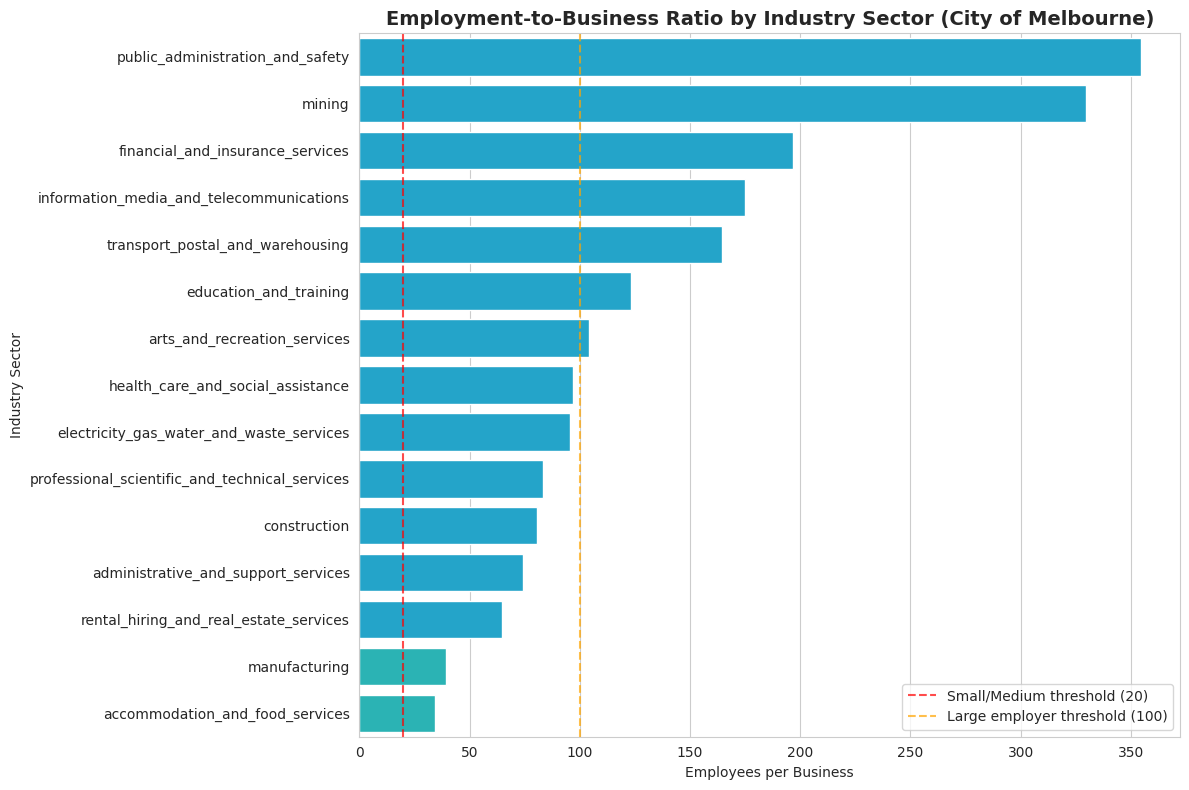

In [8]:
top_sectors = df_merged_city_sorted.head(15)

plt.figure(figsize=(12, 8))
colors = [MOP_COLOR if x < 20 else '#14c9cb' if x < 50 else '#08b3e5' for x in top_sectors['employment_to_business_ratio']]
sns.barplot(data=top_sectors, x='employment_to_business_ratio', y='industry_sector', palette=colors)
plt.title('Employment-to-Business Ratio by Industry Sector (City of Melbourne)', fontsize=14, fontweight='bold')
plt.xlabel('Employees per Business')
plt.ylabel('Industry Sector')
plt.axvline(x=20, color='red', linestyle='--', alpha=0.7, label='Small/Medium threshold (20)')
plt.axvline(x=100, color='orange', linestyle='--', alpha=0.7, label='Large employer threshold (100)')
plt.legend()
plt.tight_layout()
plt.show()

The visualisation highlights industries with comparatively higher employment intensity relative to business activity across Melbourne. Industries with larger employment concentrations may indicate workforce-intensive economic sectors.

### <div class="usecase-subsection-header">Business Count vs Employment Relationship</div>

This visualisation compares business counts and employment levels across industries to identify sectors with higher workforce intensity relative to business activity.

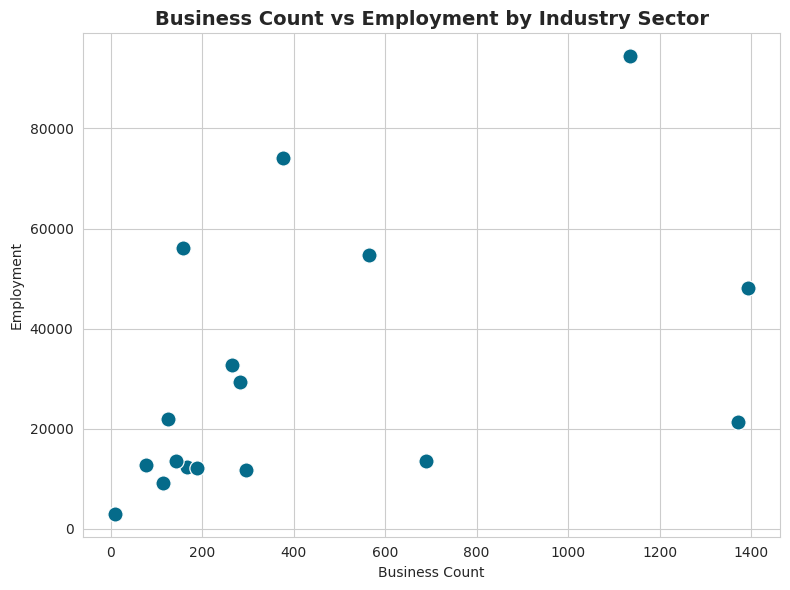

In [9]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_merged_city,
    x='business_count',
    y='jobs',
    s=120,
    color='#056b8a'
)

plt.title('Business Count vs Employment by Industry Sector',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Business Count')
plt.ylabel('Employment')

plt.tight_layout()
plt.show()

This comparison helps identify relationships between business density and workforce distribution across industries. Variations between business counts and employment levels may reflect differences in industry structure and operational scale.

Industries with relatively lower business counts but higher employment levels may indicate workforce-intensive sectors, while industries with higher business counts and lower employment may represent smaller or distributed business operations.

### <div class="usecase-subsection-header">Step 8: Geographic Hotspot Analysis – Top Areas by Business Activity</div>

This section performs geographic analysis to identify Melbourne small areas with high business concentration. Spatial analysis supports location-based interpretation of economic activity patterns across the city.

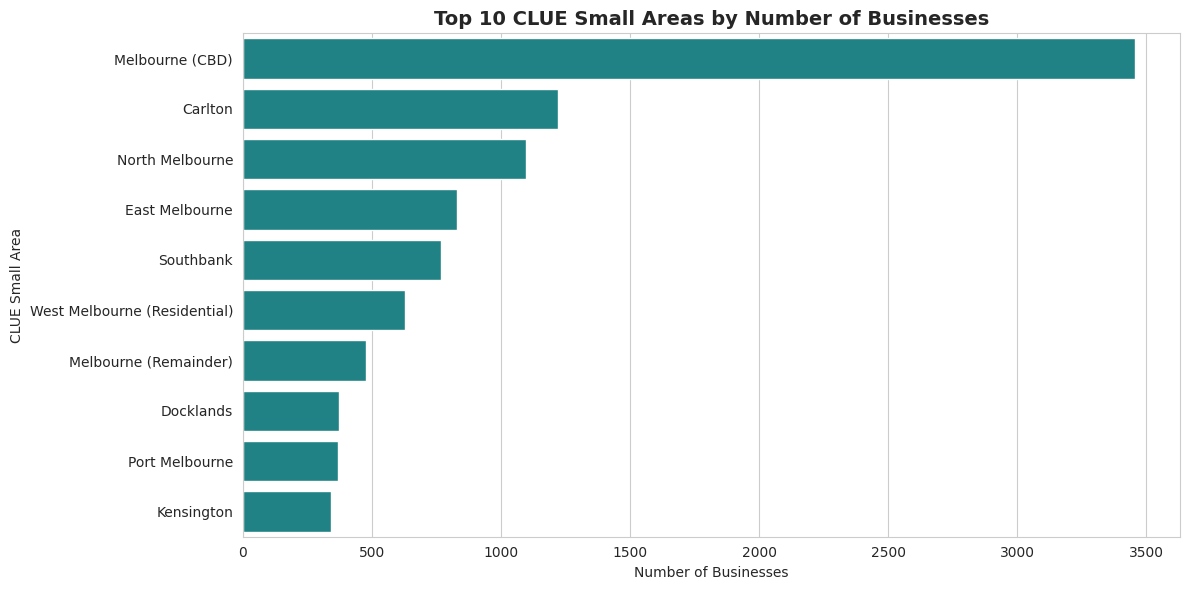

In [10]:
top_areas = business_by_area.nlargest(10, 'business_count')

plt.figure(figsize=(12, 6))
sns.barplot(data=top_areas, x='business_count', y='clue_small_area', color=MOP_COLOR)
plt.title('Top 10 CLUE Small Areas by Number of Businesses', fontsize=14, fontweight='bold')
plt.xlabel('Number of Businesses')
plt.ylabel('CLUE Small Area')
plt.tight_layout()
plt.show()

The analysis identifies Melbourne small areas with higher concentrations of business activity, highlighting regions that may function as key economic or commercial hubs within the city.



### <div class="usecase-subsection-header">Step 9: Interactive Map of Business Locations</div>

An interactive Folium map is generated to visualise business activity geographically across Melbourne. The map improves interpretability by allowing users to explore spatial business distribution patterns interactively.

In [11]:
map_center = [-37.8136, 144.9631]
business_map = folium.Map(location=map_center, zoom_start=14, control_scale=True)

# Sample 2000 businesses for performance
sample = df_business_clean.dropna(subset=['latitude', 'longitude']).head(2000)

for _, row in sample.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=2,
        color=MOP_COLOR,
        fill=True,
        fill_opacity=0.5,
        popup=row.get('industry_anzsic4_description', 'Business')
    ).add_to(business_map)

business_map

The interactive map provides a geographic overview of business concentration and economic activity across Melbourne small areas. Spatial patterns visible in the map support location-based interpretation and exploration of business distribution trends.

### <div class="usecase-section-header">Key Insights and Recommendations</div>

The analysis identified noticeable relationships between business distribution and employment concentration across Melbourne industries and locations. Interactive mapping and comparative visualisations highlighted areas with concentrated economic activity and industries with varying employment intensity. Future enhancements may include predictive modelling, additional economic indicators, and deeper temporal analysis to support more advanced business and urban planning insights.

**What we learned:**
- Industries like **Hospitals, Manufacturing, and Education** have high employment-to-business ratios (50+ employees per business). These are major employment anchors.
- **Cafes, Retail, and Personal Services** have low ratios (5-15 employees per business). These support local economies but don't create large employment centres.
- **Melbourne CBD** has the highest business concentration, but many suburban CLUE areas have high business counts with lower employment – potential growth zones.

Overall, the analysis demonstrates how integrating multiple Melbourne Open Data datasets can support understanding of business distribution, employment concentration, and broader economic activity patterns across Melbourne.

**Recommendations for economic planners:**
1. Attract large employers (hospitals, corporate HQs) to areas with high business density but low employment
2. Support micro-businesses with shared resources and co-working spaces in high-density low-employment areas
3. Improve transport infrastructure in high-employment areas to reduce congestion

**Limitation**: The Jobs per ANZSIC dataset is only available at the whole‑of‑municipality level. Therefore, the employment‑to‑business ratio can only be calculated city‑wide. Geographic gaps are shown via business density (map and top areas), not ratio by area.

**Next steps for further analysis:**
- Compare across multiple census years to identify trends
- Correlate with demographic data (population, age, income)
- Build a predictive model for employment growth by industry

### <div class="usecase-section-header">References</div>

- City of Melbourne Open Data Portal: https://data.melbourne.vic.gov.au/
- Business Establishments dataset: https://data.melbourne.vic.gov.au/explore/dataset/business-establishments-with-address-and-industry-classification/
- Jobs per ANZSIC dataset: https://data.melbourne.vic.gov.au/explore/dataset/jobs-per-anzsic-in-municipality/
- ABS ANZSIC classification: https://www.abs.gov.au/anzsic